In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = pd.read_csv('car_price_prediction_.csv')
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


Cleaning

In [25]:
df.isna().sum()

Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   str    
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   str    
 5   Transmission  2500 non-null   str    
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   str    
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   str    
dtypes: float64(2), int64(3), str(5)
memory usage: 195.4 KB


In [27]:
df.Brand.unique()

<StringArray>
['Tesla', 'BMW', 'Audi', 'Ford', 'Honda', 'Mercedes', 'Toyota']
Length: 7, dtype: str

In [28]:
df.duplicated().sum()

np.int64(0)

Task was destroyed but it is pending!
task: <Task pending name='Task-117' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\momen\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-118' coro=<Kernel.shell_main() running at C:\Users\momen\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\momen\AppData\Local\Programs\Python\Python313\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\momen\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arrays\string_.py:791: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  new_string_array = cls.__new__(cls)
Task was destroyed but it is pending!
task: <Task pending name='Task-118' coro=<Kernel.shell_main() running at C:\Users\momen\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykern

<Axes: >

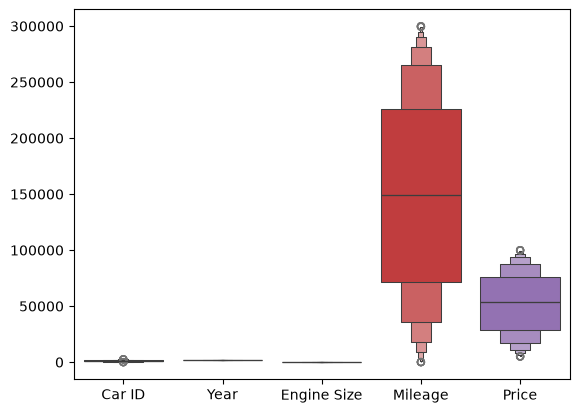

In [29]:
sns.boxenplot(data = df) # that's cool no outliear

In [30]:
# EDA

In [31]:
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [32]:
df.groupby('Brand')['Car ID'].count() # clases is balanced

Brand
Audi        368
BMW         358
Ford        347
Honda       352
Mercedes    353
Tesla       348
Toyota      374
Name: Car ID, dtype: int64

In [33]:
df.corr(numeric_only=True).index

Index(['Car ID', 'Year', 'Engine Size', 'Mileage', 'Price'], dtype='str')

In [34]:
df.loc[:,['Year', 'Engine Size', 'Mileage', 'Price']].corr(numeric_only=True)#weak relation

,Year,Engine Size,Mileage,Price
Year,1.000000,0.011833,0.002282,-0.036805
Engine Size,0.011833,1.000000,-0.015782,-0.004420
Mileage,0.002282,-0.015782,1.000000,-0.008567
Price,-0.036805,-0.004420,-0.008567,1.000000


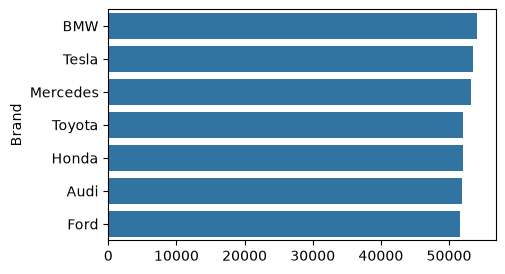

In [35]:
brand_price = df.groupby("Brand")['Price'].mean()
brand_price.sort_values(ascending=False,inplace=True)
plt.figure(figsize=(5,3))
sns.barplot(x=brand_price.values,y=brand_price.index)
plt.show()

In [36]:
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


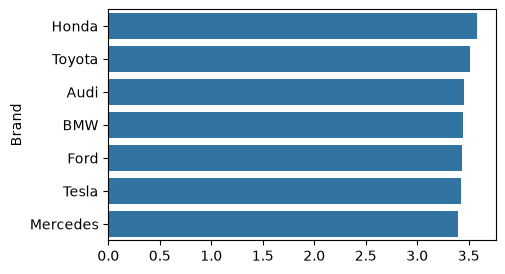

In [37]:
brand_price = df.groupby("Brand")['Engine Size'].mean()
brand_price.sort_values(ascending=False,inplace=True)
plt.figure(figsize=(5,3))
sns.barplot(x=brand_price.values,y=brand_price.index)
plt.show()

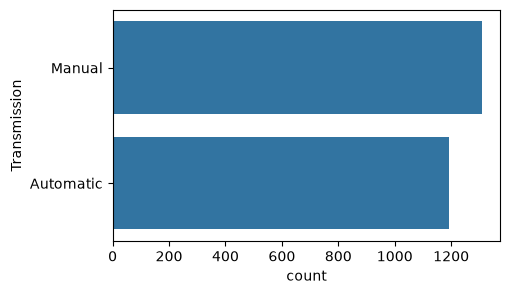

In [38]:
plt.figure(figsize=(5,3))
sns.countplot(data=df["Transmission"])
plt.show()

<Axes: xlabel='count', ylabel='Brand'>

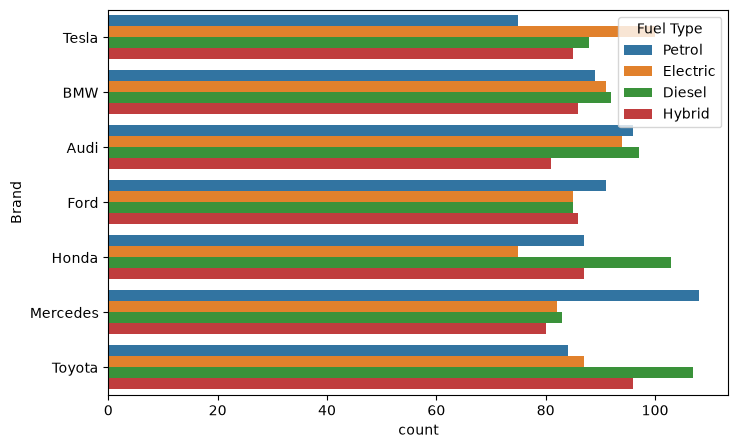

In [39]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,y='Brand',hue='Fuel Type')

<Axes: xlabel='Price', ylabel='Count'>

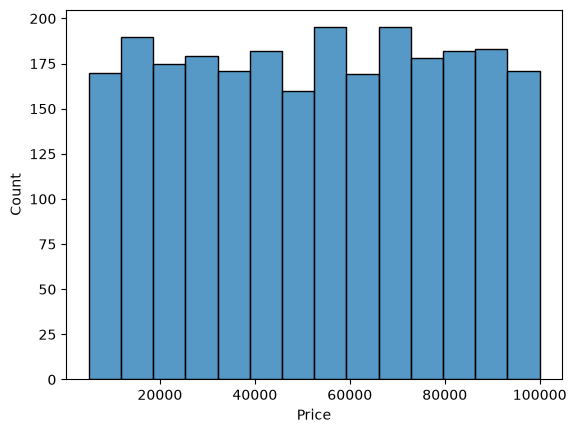

In [43]:
sns.histplot(data=df["Price"])

<Axes: xlabel='Mileage', ylabel='Price'>

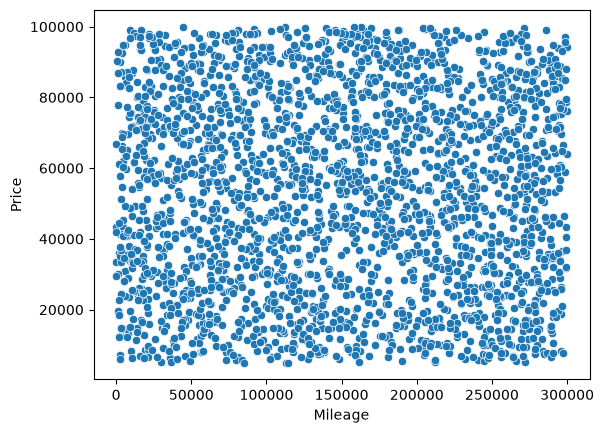

In [46]:
sns.scatterplot(data= df,x="Mileage",y = 'Price')#no reation

<Axes: xlabel='Year', ylabel='Price'>

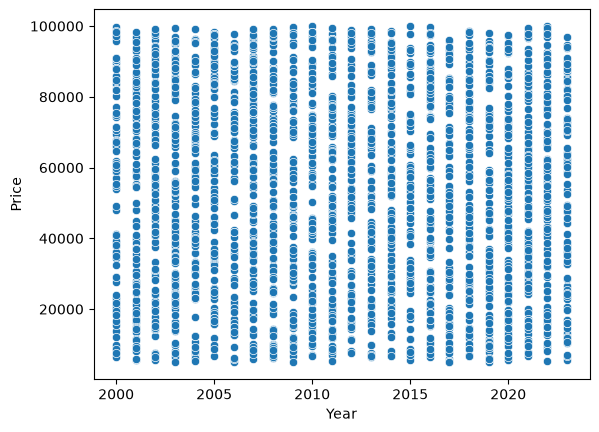

In [48]:
sns.scatterplot(data= df,x="Year",y = 'Price')#no reation

<Axes: xlabel='Fuel Type', ylabel='Price'>

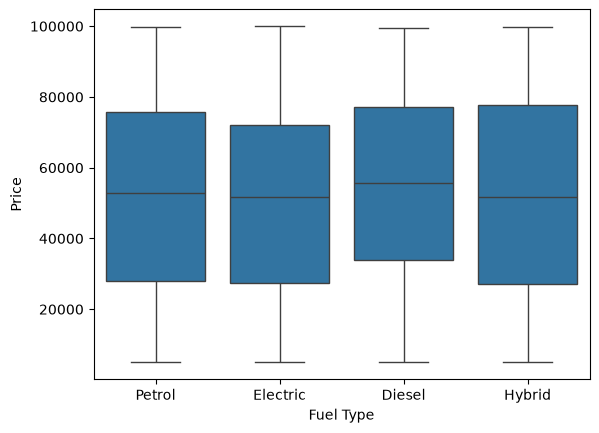

In [50]:
sns.boxplot(data= df,x="Fuel Type",y = 'Price')#no reation

<Axes: xlabel='Transmission', ylabel='Price'>

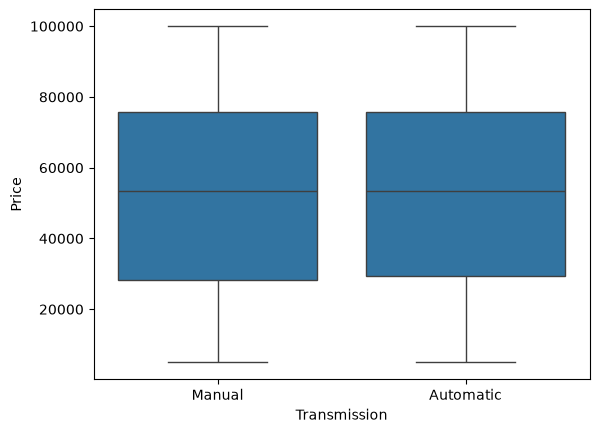

In [52]:
sns.boxplot(data= df,x="Transmission",y = 'Price')#no reation


<Axes: >

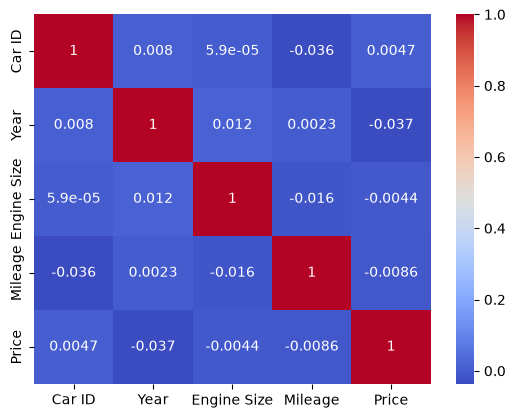

In [53]:
corr = df.select_dtypes('number').corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)